# 显微成像设备粗对准靶标图案实施例

本 notebook 给出六种可参数化绘制的粗对准靶标。第一种为分级加密放射线对照方案；其余方案分别利用共同曲率中心、嵌套轮廓中心、箭头指向、正交间距编码和旋转对称中心，在中心尚未进入小视场或只看到局部图案时提供回中线索。

> 专利撰写提示：可将各图案概括为“中心基准标记 + 分布于外围的方向引导标记”。引导标记的间距、线宽、尺度、灰度或周期可沿远离中心的方向渐变；图示参数仅用于说明，不限定实际尺寸和比例。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon

plt.rcParams.update({"figure.dpi": 120, "axes.linewidth": 0.6})

def _prepare_ax(ax=None, radius=1.0):
    """Create or normalize a square, axis-free drawing canvas."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 5))
    margin = 1.05 * radius
    ax.set(xlim=(-margin, margin), ylim=(-margin, margin), aspect="equal")
    ax.axis("off")
    return ax

def _draw_center_cross(ax, size, linewidth=1.8, color="black"):
    ax.plot([-size, size], [0, 0], color=color, lw=linewidth, zorder=10)
    ax.plot([0, 0], [-size, size], color=color, lw=linewidth, zorder=10)


## 1. 分级加密放射线（对照方案）

基础射线贯穿中心；更高角向采样率的射线仅从较外圈开始出现。因此越靠外单位角度内的可见线段越多，同时每条线段所在直线均可反向延伸至中心。

In [2]:
def draw_hierarchical_radial_guide(ax=None, radius=1.0, base_rays=8, levels=4,
                                   inner_radius=0.11, color="black"):
    """Draw radial line segments whose angular density increases outward."""
    ax = _prepare_ax(ax, radius)
    for level in range(levels):
        count = base_rays * (2 ** level)
        start = inner_radius if level == 0 else radius * (level / levels)
        angles = 2 * np.pi * (np.arange(count) + 0.5 * (level % 2)) / count
        for theta in angles:
            ax.plot([start * np.cos(theta), radius * np.cos(theta)],
                    [start * np.sin(theta), radius * np.sin(theta)],
                    color=color, lw=max(0.45, 1.05 - 0.16 * level))
    _draw_center_cross(ax, 0.13 * radius)
    return ax


## 2. 外密内疏同心环

通过局部圆弧的曲率即可推断中心方向；环间距向外逐渐减小，可同时编码距中心的大致区间。实际加工时也可将完整圆环替换为断续圆弧或不同占空比的环带。

In [3]:
def draw_chirped_concentric_rings(ax=None, radius=1.0, ring_count=18,
                                  exponent=0.62, color="black"):
    """Draw concentric rings with spacing that decreases toward the outside."""
    ax = _prepare_ax(ax, radius)
    u = np.linspace(0.16, 1.0, ring_count)
    radii = radius * u ** exponent
    for i, r in enumerate(radii):
        ax.add_patch(Circle((0, 0), r, fill=False, color=color,
                            lw=1.15 if i % 4 == 0 else 0.65))
    _draw_center_cross(ax, 0.12 * radius)
    return ax


## 3. 嵌套菱形轮廓

各级菱形共享几何中心，其边缘斜率给出两个对角方向。外圈间距逐渐减小，且周期性加粗轮廓可作为尺度编码，便于区分当前位于近中心区还是远中心区。

In [4]:
def draw_nested_diamonds(ax=None, radius=1.0, count=16, exponent=0.64,
                         color="black"):
    """Draw shared-center diamond contours with outward chirped spacing."""
    ax = _prepare_ax(ax, radius)
    scales = radius * np.linspace(0.15, 1.0, count) ** exponent
    for i, s in enumerate(scales):
        vertices = np.array([[0, s], [s, 0], [0, -s], [-s, 0]])
        ax.add_patch(Polygon(vertices, closed=True, fill=False, color=color,
                             lw=1.2 if i % 4 == 0 else 0.65))
    _draw_center_cross(ax, 0.11 * radius)
    return ax


## 4. 四向汇聚人字标

四组重复 V 形标记的尖端均朝向中心。即使中心位于视场外，局部人字形的开口方向也能直接指示载台移动方向；不同位置可采用不同线宽、长度或重复周期来表示离中心的级别。

In [5]:
def draw_converging_chevrons(ax=None, radius=1.0, rows=7, color="black"):
    """Draw four banks of chevrons whose tips point toward the center."""
    ax = _prepare_ax(ax, radius)
    distances = radius * np.linspace(0.30, 0.94, rows) ** 0.78
    for direction in range(4):
        phi = direction * np.pi / 2
        inward = np.array([-np.cos(phi), -np.sin(phi)])
        tangent = np.array([-np.sin(phi), np.cos(phi)])
        for i, d in enumerate(distances):
            center = -d * inward
            length = 0.13 * radius
            half_width = (0.075 + 0.008 * i) * radius
            tip = center + 0.55 * length * inward
            back = center - 0.45 * length * inward
            p1, p2 = back + half_width * tangent, back - half_width * tangent
            ax.plot([p1[0], tip[0], p2[0]], [p1[1], tip[1], p2[1]],
                    color=color, lw=0.75 + 0.08 * (i % 3))
    _draw_center_cross(ax, 0.12 * radius)
    return ax


## 5. 二维变间距正交网格

横向和纵向线列均以中心轴为对称轴，线间距向外围递减。操作者可分别根据水平、竖直方向的局部周期变化判断 X/Y 回中方向；中心轴加粗后形成唯一的二维基准交点。

In [6]:
def draw_chirped_cartesian_grid(ax=None, radius=1.0, lines_per_side=12,
                                exponent=0.60, color="black"):
    """Draw an orthogonal grid with line spacing decreasing away from center."""
    ax = _prepare_ax(ax, radius)
    u = np.linspace(0.12, 1.0, lines_per_side) ** exponent
    positions = radius * np.r_[-u[::-1], 0.0, u]
    for i, p in enumerate(positions):
        lw = 1.65 if np.isclose(p, 0) else (0.95 if i % 5 == 0 else 0.48)
        ax.plot([p, p], [-radius, radius], color=color, lw=lw)
        ax.plot([-radius, radius], [p, p], color=color, lw=lw)
    ax.add_patch(Circle((0, 0), 0.055 * radius, color="white", zorder=8))
    _draw_center_cross(ax, 0.12 * radius)
    return ax


## 6. 双臂螺旋引导标记

两条相差 180° 的螺旋线共享唯一旋转中心。局部切线方向和曲率随半径连续变化，可用于拟合中心位置；双臂结构可降低单条螺旋方向不对称带来的识别歧义。

In [7]:
def draw_double_spiral(ax=None, radius=1.0, turns=4.5, samples=1800,
                       color="black"):
    """Draw two interleaved Archimedean spiral arms with a common center."""
    ax = _prepare_ax(ax, radius)
    theta = np.linspace(0, turns * 2 * np.pi, samples)
    r = radius * (0.07 + 0.93 * theta / theta.max())
    for phase in (0, np.pi):
        ax.plot(r * np.cos(theta + phase), r * np.sin(theta + phase),
                color=color, lw=0.8)
    _draw_center_cross(ax, 0.11 * radius)
    return ax


## 总览与调用示例

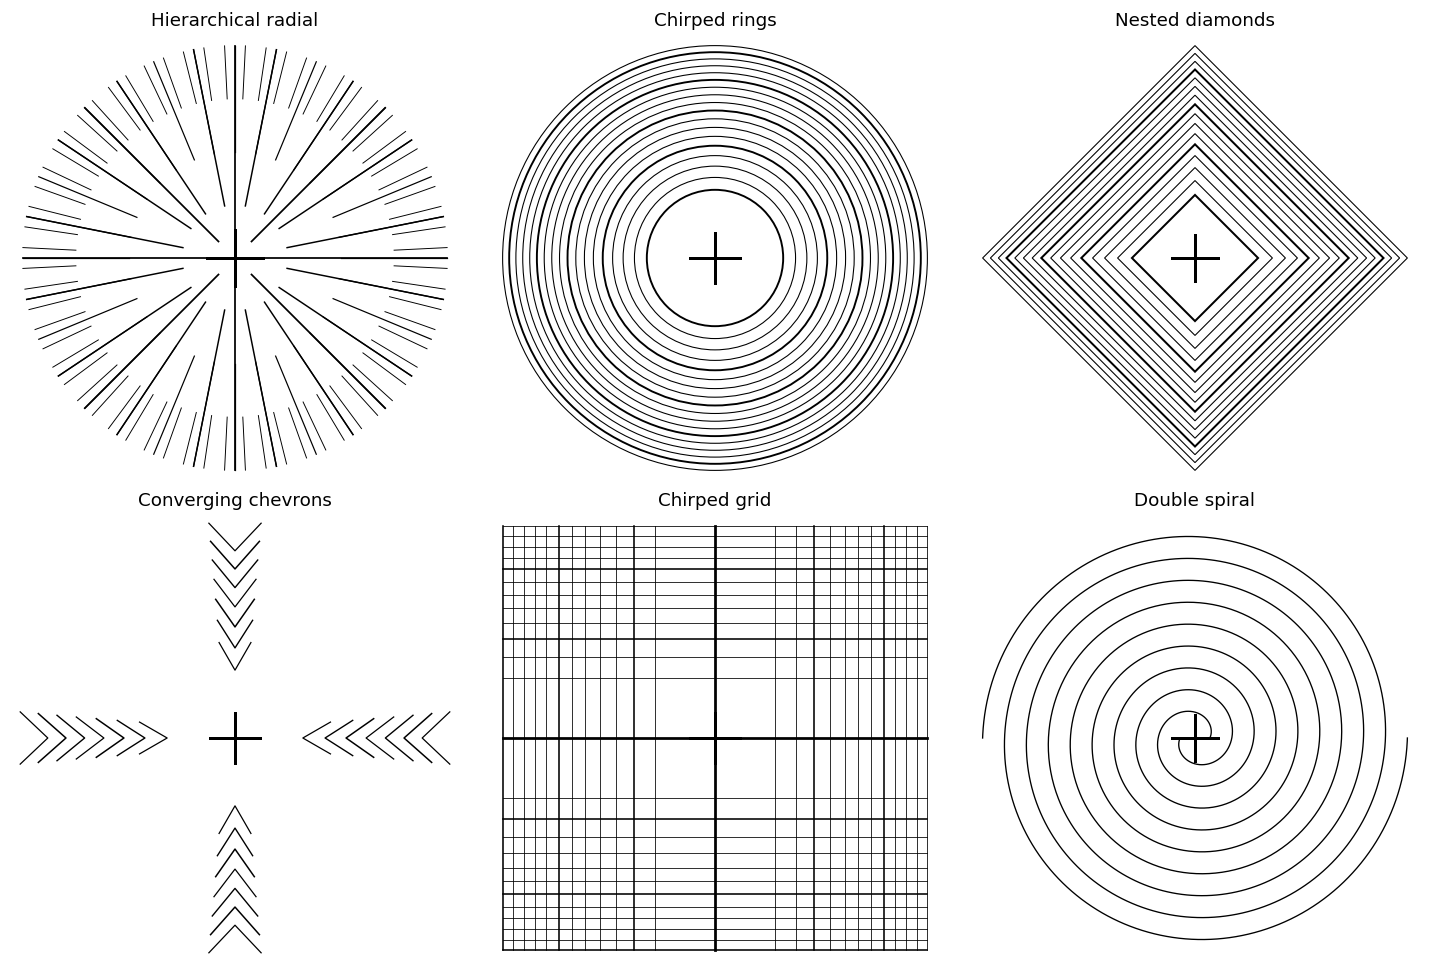

In [8]:
patterns = [
    ("Hierarchical radial", draw_hierarchical_radial_guide),
    ("Chirped rings", draw_chirped_concentric_rings),
    ("Nested diamonds", draw_nested_diamonds),
    ("Converging chevrons", draw_converging_chevrons),
    ("Chirped grid", draw_chirped_cartesian_grid),
    ("Double spiral", draw_double_spiral),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)
for ax, (title, draw) in zip(axes.flat, patterns):
    draw(ax=ax)
    ax.set_title(title, fontsize=11)
plt.show()

## 可作为权利要求从属特征的参数变化

- 引导线的间距、线宽、长度、占空比、灰度或颜色随半径分级或连续变化。
- 完整轮廓可替换为断续线段，并通过断口方位编码象限或移动方向。
- 图案可单独使用，也可叠加在原十字靶标外围；不同尺度的图案可分层布置，以覆盖不同倍率和视场。
- 图案可制作为透射、反射、相位、荧光或高度差结构；中心十字也可替换为圆点、套刻框或其他精对准标记。
- 图像处理端可通过直线交汇、圆/椭圆拟合、轮廓对称、局部周期梯度或螺旋模型拟合估算中心偏移量。